### import libraries

In [2]:
import os
import yaml

import numpy as np
import matplotlib.pyplot as plt
from XLO_sim.XLO_sim import XLO_sim
from XLO_sim.Plot import XLO_plot
from XLO_sim import tools

import numpy.fft as fft

import scipy.constants as sp_const
au_in_eV = sp_const.value('atomic unit of energy') / sp_const.value('atomic unit of charge')

import multiprocessing as mp
import shutil

import pandas as pd

notebook_path = os.path.abspath("__file__")
notebook_directory = os.path.dirname(notebook_path)
base_directory = os.path.dirname(notebook_directory)

initializing ocelot...


### Transmission

In [3]:
tpad = 1000
xpad = 64
ypad = 64

th_show = 2
w_show = 5

thx_show_min = -th_show
thx_show_max = th_show
thy_show_min = -th_show
thy_show_max = th_show
w_show_min = -w_show
w_show_max = w_show

### reading and plotting

In [4]:
figs_path = os.path.join(base_directory, 'figs')
if not os.path.exists(figs_path):
    os.makedirs(figs_path)

In [5]:
Tshow_min = 0.15#0.4
Tshow_max = 0.5
w_show = 15
w_show_min = -w_show
w_show_max = w_show

In [6]:
data_path = "../data/intensity_sweep_2_level"

sorted_accumulated_arrays, aux_data, num_files = tools.data_from_folder(
    data_path, group_keys='E_seed_uJ',
    aux_keys=['tgrid', 'xgrid', 'ygrid', 'zgrid', 'sigma1_Ka1_2p3', 
              'sigma1_Ka1_other', 'seed_duration_FWHM_t', 'seed_width_FWHM_x', 'seed_width_FWHM_y'],
)

tgrid, xgrid, ygrid, zgrid, sigma1_Ka1_2p3, sigma1_Ka1_other, seed_duration_FWHM_t, seed_width_FWHM_x, seed_width_FWHM_y = aux_data

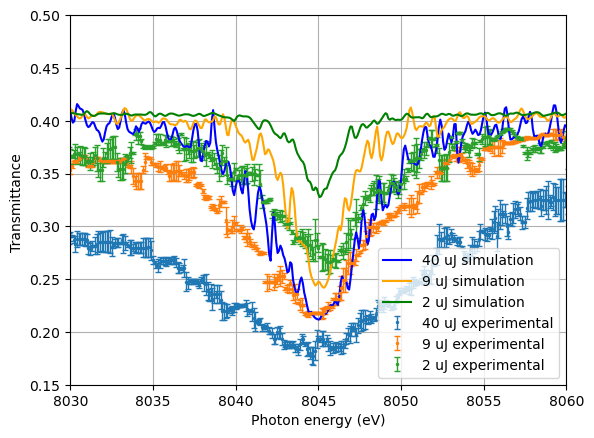

In [9]:
experimental_df = pd.read_csv("../data/transmittance_2_9_40uJ.csv")
plt.errorbar(experimental_df["Photon_energy_eV"], experimental_df["40uJ_transmittance"], 
             experimental_df["40uJ_error"], label="40 uJ experimental", 
             fmt='.', capsize=2, ms=3, elinewidth=1)
plt.errorbar(experimental_df["Photon_energy_eV"], experimental_df["9uJ_transmittance"], 
             experimental_df["9uJ_error"], label="9 uJ experimental", 
             fmt='.', capsize=2, ms=3, elinewidth=1)
plt.errorbar(experimental_df["Photon_energy_eV"], experimental_df["2uJ_transmittance"], 
             experimental_df["2uJ_error"], label="2 uJ experimental", 
             fmt='.', capsize=2, ms=3, elinewidth=1)

E_seed_values = list(sorted_accumulated_arrays.keys())

colors = {
    40: "blue",
    9: "orange",
    2: "green"
}

hwKalpha1N = 8045

for E_seed_value, arrays in sorted_accumulated_arrays.items():
    womega_ar = arrays['womega_ar']
    I_int_thy_w_last = arrays['I_int_thy_w_last']
    I_int_thy_w_0 = arrays['I_int_thy_w_0']
    
    Tint_w = I_int_thy_w_last / I_int_thy_w_0

    energy_eV = hwKalpha1N + womega_ar
    
    plt.plot(energy_eV, Tint_w, color=colors[E_seed_value], label = str(E_seed_value) + ' uJ simulation')
    
plt.ylabel('Transmittance ')
plt.xlabel('Photon energy (eV)')
plt.ylim(Tshow_min, Tshow_max)
plt.xlim(hwKalpha1N - 15, hwKalpha1N + 15)
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
intensity_df = pd.read_csv("../data/intensity.csv")

I_int_thy_w_0 = sorted_accumulated_arrays[40]['I_int_thy_w_0']
plt.plot(energy_eV, I_int_thy_w_0/I_int_thy_w_0.min(), label="Simulation")
plt.plot(intensity_df["Photon_energy_eV"], intensity_df["Intensity"]/intensity_df["Intensity"].max(), label="Experiment")
plt.xlim(8000, 8100)
plt.legend()
plt.show()